# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: 'Trebuchet MS', sans-serif; color: white; font-size: 160%; text-align: center; border-radius: 16px; padding: 18px 10px; letter-spacing: 3px; text-shadow: 1px 1px 4px #000;">💳 Capstone Project &nbsp;|&nbsp;  Fraud Detection</p>

<img src="https://i.postimg.cc/Jz9S0QnF/resized-jupyter.png" width="1200" style="border-radius:14px; margin-top:6px;">

<div style="border-radius:14px; padding:20px 22px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:116%; margin-top:10px"> <h3 style="color:#1a0533; margin-top:0">🚨 Problem Statement</h3>

In the era of digital finance, fraudulent transactions occur rapidly and often go unnoticed, leading to significant financial losses. This project aims to build a machine learning pipeline to <b>detect fraudulent financial transactions</b> from a dataset of mobile money transfers.

We will first verify whether the dataset is balanced or imbalanced during the loading dataset. If the dataset is highly imbalanced, where fraudulent transactions represent only a small fraction of the data, we will focus on evaluation metrics such as <b>Recall</b> for the fraud class and maintain a balance with <b>Precision</b>, rather than relying on overall accuracy. The goal is to effectively identify fraud while minimizing false alarms.

</div>

<div style="border-radius:14px; padding:20px 22px; background:#f3f0ff; border-left:7px solid #1a0533; font-size:115%; margin-top:6px">
<h3 style="color:#1a0533; margin-top:0">🎯 Project Objectives</h3>

<ul>
<li><b>Dataset Exploration</b> — Perform an initial analysis to understand transaction types, data distribution, class imbalance, and the overall proportion of fraudulent vs. legitimate transactions.</li>

<li><b>Exploratory Data Analysis (EDA)</b> — Identify key patterns, trends, and anomalies that differentiate fraudulent transactions from genuine ones using statistical summaries and visualizations.</li>

<li><b>Data Preprocessing</b>:
  <ul>
    <li>Remove non-informative or identifier columns that do not contribute to prediction</li>
    <li>Handle missing values using appropriate imputation techniques (if present)</li>
    <li>Create meaningful features such as balance differences to enhance model performance</li>
    <li>Encode categorical variables using One-Hot Encoding for model compatibility</li>
    <li>Detect and treat outliers in critical numerical features like transaction amount and account balances</li>
    <li>Apply feature scaling to ensure all numerical variables are on a comparable scale</li>
  </ul>
</li>

<li><b>Model Development</b> — Build and optimize multiple classification models, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting, to detect fraudulent transactions.</li>

<li><b>Model Evaluation & Comparison</b> — Assess model performance using key metrics such as F1-Score, Recall, Precision, and ROC-AUC, with a strong focus on recall to minimize false negatives in fraud detection.</li>

</ul>
</div>

<a id="toc"></a>
<div style="border-radius:14px; padding:20px 22px; background:#f3f0ff; border-left:7px solid #059669; font-size:115%; margin-top:6px">
<h3 style="color:#1a0533; margin-top:0">📋 Table of Contents</h3>

* [Step 1 | Import Libraries](#s1)
* [Step 2 | Load Dataset](#s2)
* [Step 3 | Dataset Overview](#s3)
  - [Step 3.1 | Shape & Info](#s31)
  - [Step 3.2 | Statistical Summary](#s32)
  - [Step 3.3 | Unique Values Inspection](#s33)
  - [Step 3.4 | Feature Dictionary](#s34)
  - [Step 3.5 | Check Fraud vs Non-Fraud Counts](#s35)
* [Step 4 | Exploratory Data Analysis](#s4)
  - [Step 4.1 | Correlation Heatmap](#s41)
  - [Step 4.2 | Visual EDA — 6 Perspectives](#s42)
* [Step 5 | Data Preprocessing](#s5)
  - [Step 5.1 | Null Value Check](#s51)
  - [Step 5.2 | Drop Irrelevant Columns](#s52)
  - [Step 5.3 | Feature Engineering](#s53)
  - [Step 5.4 | Outlier Treatment](#s54)
  - [Step 5.5 | Categorical Encoding](#s55)
* [Step 6 | Feature Scaling & Train-Test Split](#s6)
* [Step 7 | Create a function for GridSearchCV](#s7)
  - [Step 7.1 | Reusable Grid Search Function](#s71)
  - [Step 7.2 | Parameter Grids](#s72)
* [Step 8 | Models Training](#s8)
* [Step 9 | Model Evaluation](#s9)
  - [Step 9.1 | Model Training on Unseen Data](#s91)
  - [Step 9.2 | Model Training on Seen Data](#s92)
  - [Step 9.3 | Confusion Matrix ](#s93)
* [Step 10 | Conclusion ](#s10)
* [Step 11 | Model and Scaler Export for Depolyment  ](#s11)
</div>


<h3 style="color:#1a0533; font-family: Trebuchet MS;"> 🕵️Let's trace the fraud trail — step by step.</h3>

<a id="s1"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 1 &nbsp;|&nbsp; Import Libraries</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%">
This section initializes all the necessary libraries used throughout the project, ranging from data manipulation and visualization to machine learning. The imports are systematically organized based on their specific roles in the workflow to maintain clarity and readability.
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, 
                            precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay)

print("✅ ALL Libraries imported successfully")

✅ ALL Libraries imported successfully


<a id="s2"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 2 &nbsp;|&nbsp; Load Dataset</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

In [2]:
# Read the dataset.
df = pd.read_excel("Fraud_Analysis_Dataset.xlsx")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


<a id="s3"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 3 &nbsp;|&nbsp; Dataset Overview</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<a id="s31"></a>
## <span style="color:#7c3aed">Step 3.1</span> <span style="color:#1a0533"> | Shape & Info</span>

In [4]:
# display the concise summary of the dataframe.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #059669; font-size:114%">

<b style="color:#1a0533">📊 Data Types Summary:</b><br>

<b>Entries:</b> 11,142 rows (0 to 11,141)<br>
<b>Columns:</b> 10 features<br>
<b>Non-Null Values:</b> No missing values (all columns have 11,142 non-null entries)<br>

<b>Data Types Distribution:</b><br>
- <b>Float:</b> 5 columns (transaction amounts & balances)<br>
- <b>Integer:</b> 2 columns (<code>step</code>, <code>isFraud</code>)<br>
- <b>Object:</b> 3 columns (<code>type</code>, <code>nameOrig</code>, <code>nameDest</code>)<br>

</div>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #059669; font-size:114%">

<b><span style="font-size:130%; color:red">Note:</span></b> <code>type</code> is a categorical feature and needs encoding. Columns like <code>nameOrig</code> and <code>nameDest</code> are identifiers and can be dropped as they do not add predictive value.

</div>


<a id="s32"></a>
## <span style="color:#7c3aed">Step 3.2</span> <span style="color:#1a0533"> | Statistical Summary</span>

In [5]:
# Display the statastical summary of the dataframe.
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #059669; font-size:114%">

<b style="color:#1a0533">📊 Statistical Summary:</b><br>

<b>Transactions:</b> Amounts vary widely (min ≈ 2, max ≈ 10M), indicating presence of extreme values.<br>
<b>Balances:</b> Account balances show large variation with many zero values, suggesting inactive or empty accounts.<br>
<b>Distribution:</b> High difference between median and max values → data is highly skewed.<br>
<b>Fraud Rate:</b> Mean of <code>isFraud</code> ≈ 0.10 → around <b>10% transactions are fraudulent</b>.<br>
<b>Time Feature:</b> <code>step</code> ranges from 1 to 95, where each step represents one hour.

</div>

<a id="s33"></a>
## <span style="color:#7c3aed">Step 3.3</span> <span style="color:#1a0533"> | Unique Values Inspection</span>

In [6]:
# Loop through selected columns and their unique values.
# Just verify the unique values to encoding 
columns = ["type","isFraud"]

for i in columns:
    print(i, "=", df[i].unique())

type = ['TRANSFER' 'CASH_OUT' 'PAYMENT' 'DEBIT' 'CASH_IN']
isFraud = [1 0]


<a id="s34"></a>
## <span style="color:#7c3aed">Step 3.4</span> <span style="color:#1a0533"> | Feature Dictionary</span>

<div style="border-radius:14px; padding:18px 22px; background:#f3f0ff; border-left:7px solid #1a0533; font-size:113%">
<b style="color:#1a0533">📖 Column Reference Guide</b>

| **Column** | **Type** | **Description** |
|:---|:---|:---|
| `step` | Numerical | 1 step = 1 hour of real time; total 743 steps (~30 days) |
| `type` | Categorical | Transaction type: CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Numerical | Transaction amount in local currency |
| `nameOrig` | Identifier | Sender account ID — unique per customer |
| `oldbalanceOrg` | Numerical | Sender's balance **before** the transaction |
| `newbalanceOrig` | Numerical | Sender's balance **after** the transaction |
| `nameDest` | Identifier | Receiver account ID |
| `oldbalanceDest` | Numerical | Receiver's balance **before** the transaction |
| `newbalanceDest` | Numerical | Receiver's balance **after** the transaction |
| `isFraud` | Target (0/1) | Ground truth: `1` = Fraudulent, `0` = Genuine |

> 💡 `nameOrig` and `nameDest` are unique identifiers — they carry no predictive signal and will be dropped during preprocessing.
</div>

<a id="s35"></a>
## <span style="color:#7c3aed">Step 3.5</span> <span style="color:#1a0533"> | Check Fraud vs Non-Fraud Counts </span>

In [7]:
# Check whether data is balance or imbalance
df['isFraud'].value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #059669; font-size:114%">
  <b style="color:#1a0533">📊 Discovery:</b><br><br>

  Data is imbalanced.<br>
  The dataset is highly skewed toward 
  <span style="background-color:#fde68a; padding:2px 6px; border-radius:6px;">
    non-fraudulent transactions (~90%)
  </span><br>
  This is typical for fraud detection datasets.<br>
  Using this data for modeling may make models biased toward predicting non-fraud.<br>
  Evaluation metrics like 
  <span style="background-color:#bbf7d0; padding:2px 6px; border-radius:6px;">
    ROC-AUC, F1-score, precision-recall
  </span> 
  are better than accuracy here.
</div>

<a id="s4"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 4 &nbsp;|&nbsp; Exploratory Data Analysis</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%">
EDA helps us answer the core questions before touching a single model. We look at <b>how fraud behaves differently</b> from legitimate transactions across transaction type, amount, time, and balance patterns.
</div>

<a id="s41"></a>
## <span style="color:#7c3aed">Step 4.1</span> <span style="color:#1a0533"> | Correlation Heatmap</span>

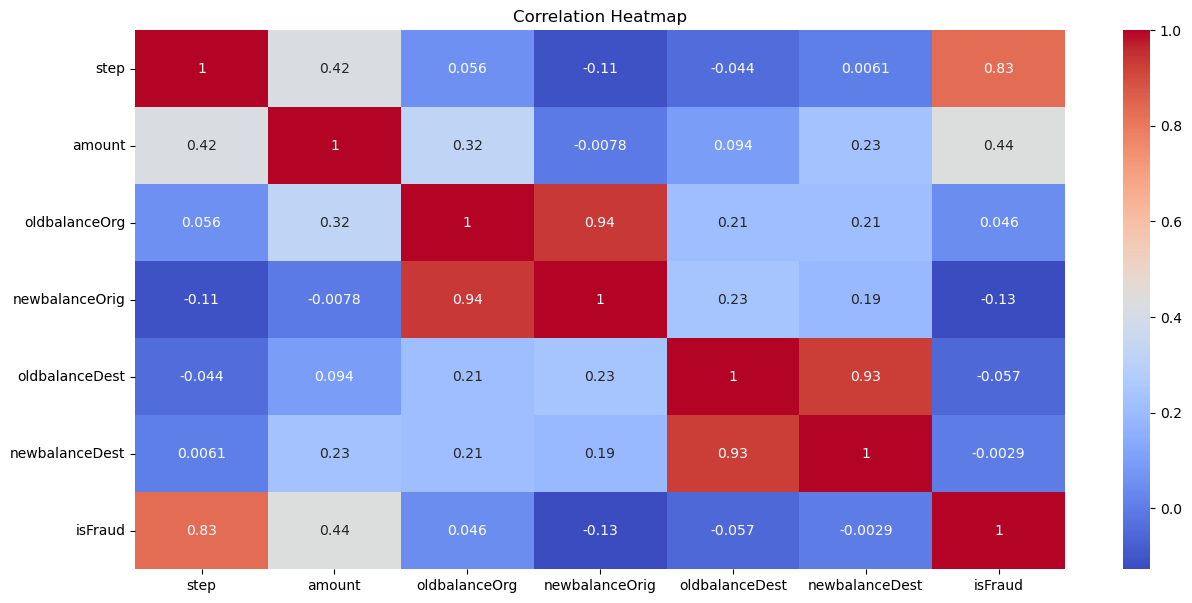

In [8]:
#Performing EDA before preprocessing.

# Perform EDA to identify important features and detect patterns
corr = df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
        'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()
plt.figure(figsize=(15,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #059669; font-size:114%">
<b style="color:#1a0533">🔎 Insights:</b>

* <b><code>amount</code></b> has the highest (though modest) positive correlation with <code>isFraud</code> — fraud tends to involve larger transactions.
* <b><code>oldbalanceOrg</code></b> and <b><code>newbalanceOrig</code></b> are strongly correlated with each other — expected, as balance after = balance before − amount.
* <b>No single feature dominates</b> — this confirms the need for a multi-feature ML model rather than simple rule-based detection.
</div>

<a id="s42"></a>
## <span style="color:#7c3aed">Step 4.2</span> <span style="color:#1a0533"> | Visual EDA — 6 Perspectives</span>

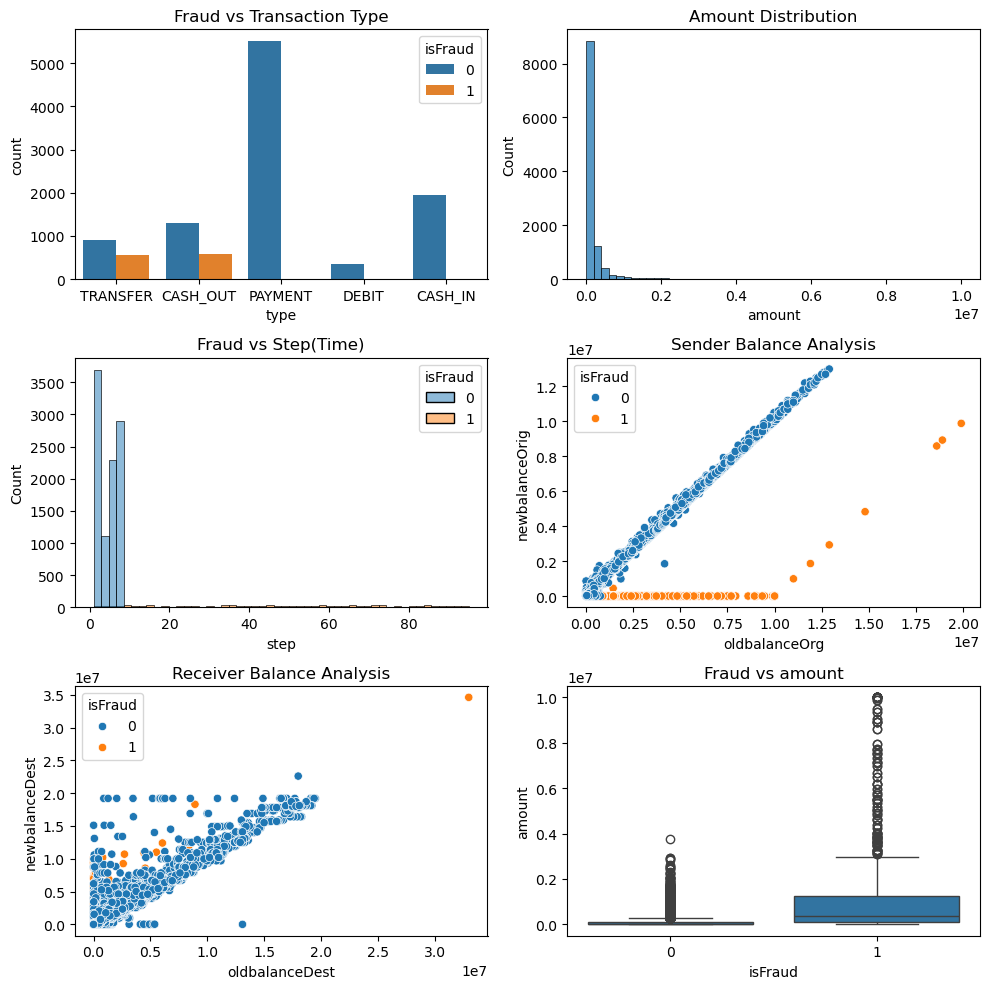

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))  # 3 rows, 2 columns, axes is a 2D array representing each subplot’s axes.

# 1. Which types have more fraud?
sns.countplot(x='type', hue='isFraud', data=df, ax=axes[0,0])
axes[0,0].set_title("Fraud vs Transaction Type")

# 2. Are fraud transactions large?
sns.histplot(df['amount'], bins=50, ax=axes[0,1])
axes[0,1].set_title("Amount Distribution")

# 3. Fraud peaks at certain times
sns.histplot(data=df, x='step', hue='isFraud', bins=50, ax=axes[1,0])
axes[1,0].set_title("Fraud vs Step(Time)")

# 4. Sender balance Analysis
sns.scatterplot(x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', data=df, ax=axes[1,1])
axes[1,1].set_title("Sender Balance Analysis")

# 5.Receiver Balance Analysis
sns.scatterplot(x='oldbalanceDest', y='newbalanceDest', hue='isFraud', data=df, ax=axes[2,0])
axes[2,0].set_title("Receiver Balance Analysis")

# 6. Fraud vs Amount 
sns.boxplot(x='isFraud', y='amount', data=df , ax=axes[2,1])
axes[2,1].set_title("Fraud vs amount")

# Adjusts spacing automatically so titles, labels, and legends don’t overlap.
plt.tight_layout()

# Display the output
plt.show()


<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%">
<b style="color:#1a0533">🔎 EDA Insights:</b>

* **Panel ①** — Fraud occurs <b>exclusively</b> in <code>CASH_OUT</code> and <code>TRANSFER</code> transactions. PAYMENT, DEBIT, and CASH_IN have zero fraud cases — a powerful feature signal.
* **Panel ②** — Amount is heavily right-skewed. Most transactions are small; a few are very large (potential outliers to treat).
* **Panel ③** — Fraud spikes are slightly more concentrated in early hours, but not dramatically different from legitimate activity.
* **Panel ④ & ⑤** —Panel ④ & ⑤ — When a fraud happens, the person sending the money often ends up with nothing left in their account. The person receiving the money sometimes starts with zero money, which is a sign of “mule accounts” (fake or temporary accounts used in fraud).
* **Panel ⑥** —Fraud transactions usually involve bigger amounts of money than normal transactions. This means the <code>amount</code> of money is an important clue to detect fraud.  
</div>

<a id="s5"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 5 &nbsp;|&nbsp; Data Preprocessing</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<a id="s51"></a>
## <span style="color:#7c3aed">Step 5.1</span> <span style="color:#1a0533"> | Null Value Check</span>

In [10]:
# Check whether data has null values or not.
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

<a id="s52"></a>
## <span style="color:#7c3aed">Step 5.2</span> <span style="color:#1a0533"> | Drop Irrelevant Columns</span>

In [11]:
# Remove irrelevant columns which are not contributing in fraud Predictions
df.drop(columns=["nameOrig","nameDest"], inplace=True)

<a id="s53"></a>
## <span style="color:#7c3aed">Step 5.3</span> <span style="color:#1a0533"> | Feature Engineering</span>

In [12]:
# Add insightful features that can be compared with amount
df["balance_diff_org"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [13]:
# View changes
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_org,balance_diff_dest
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0


<a id="s54"></a>
## <span style="color:#7c3aed">Step 5.4</span> <span style="color:#1a0533"> | Outlier Treatment</span>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #d97706; font-size:114%">
<b style="color:#1a0533">💡Outlier Treatment:</b>

Lage transaction amounts may look like outliers, but in fraud detection they often indicate actual fraud.
Therefore, we **do not remove or cap them**. Instead, we scale them using StandardScaler to help the model train better 
while keeping these important signals intact.

</div>

<a id="s55"></a>
## <span style="color:#7c3aed">Step 5.5</span> <span style="color:#1a0533"> | Categorical Encoding </span>

In [14]:
# Converting categorical columns into numerical values
# We use One-Hot Encoding because the "type" column is nominal (no inherent order), so Label Encoding is not suitable.
# We choose OneHotEncoder(sklearn) instead of get_dummies(pandas) because:
# 1. It integrates smoothly with scikit-learn pipelines.
# 2. It can handle unseen categories during deployment.
# 3. It can output sparse matrices for memory efficiency.
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[["type"]])

#Create new column names
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["type"]))

#merge with original dataframe
df = pd.concat([df.drop("type", axis =1), encoded_df], axis=1)

In [15]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_org,balance_diff_dest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,0.0,1.0,0.0,0.0,0.0
2,1,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,0.0,1.0,0.0,0.0,0.0
4,1,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,0.0,0.0,0.0,0.0,1.0


<a id="s6"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 6 &nbsp;|&nbsp; Feature Scaling & Train-Test Split</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%"> Feature scaling makes sure that columns with large values like <code>amount</code> (in millions) don’t dominate columns with smaller values like <code>step</code> (in hundreds). This helps models like Logistic Regression effectively.
</div>

In [16]:
# Define the input features (X) and output labels (y).

X = df.drop(columns="isFraud", axis=1)
Y = df["isFraud"]

In [17]:
# Scaling features for better predications

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
#Splitting data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X,Y, train_size=0.8, random_state=42)

<a id="s7"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 7 &nbsp;|&nbsp; Create a function for GridSearchCV </p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<a id="s71"></a>
## <span style="color:#7c3aed">Step 7.1</span> <span style="color:#1a0533"> | Reusable Grid Search Function</span>

In [19]:
# make a GridsearchCv function for all model parameters to find best one.

from sklearn.model_selection import GridSearchCV

def grid_best_params(model, param_grid, X_train, y_train):
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(x_train, y_train)
    
    return grid.best_params_

<a id="s72"></a>
## <span style="color:#7c3aed">Step 7.2</span> <span style="color:#1a0533"> | Hyperparameter Grids</span>

In [20]:
# Parameters of models 

#logistic Reression 
log_param_grid ={"C":[0.1],
            "penalty":["l2"],
            "solver":["lbfgs"],
            "class_weight":["balanced"]}

# DecisionTree Classifier
dt_param_grid = {
    "criterion":["gini", "entropy"],
    "max_depth":[3,5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,3],
    "class_weight":['balanced']
}

# 3. RandomForestClassifier
rf_param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt", "log2"],
    "class_weight":["balanced"]
    
}

# 4. GradientBoostingClassifier
gr_param_grid = {
    "loss":["log_loss", "exponential"],
    "n_estimators":[1000],
    "min_samples_split":[3,5,7],
    "min_samples_leaf":[1,2,4],
    "min_samples_split":[2,5,10],
    "max_features":["sqrt","log2"]
}

In [21]:
# Save all models in one dictonary 

models = {
    "Logistic": (LogisticRegression(), log_param_grid),
    "DecisionTree": (DecisionTreeClassifier(), dt_param_grid),
    "RandomForest": (RandomForestClassifier(), rf_param_grid),
    "GradientBoosting": (GradientBoostingClassifier(), gr_param_grid)
}

<a id="s8"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 8 &nbsp;|&nbsp; Models Training </p>
⬆️ <a href="#toc">Back to Table of Contents</a>

In [24]:
trained_models = {}

for model_name, (model, param_grid) in models.items():
    
    # Step 1: Get best parameters
    best_params = grid_best_params(model, param_grid, x_train, y_train)
    
    # Step 2: Set parameters
    model.set_params(**best_params)
    
    # Step 3: Train model
    model.fit(x_train, y_train)
    
    # Step 4: Store trained model
    trained_models[model_name] = model

<a id="s9"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 9 &nbsp;|&nbsp; Model Evaluation </p>
⬆️ <a href="#toc">Back to Table of Contents</a>

<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%">
<b style="color:#1a0533">🔎 What does meaning of Overfitting ?</b>
    
Overfitting occurs when a model learns the training data too well, including noise and unnecessary details, instead of learning the general pattern.
As a result, the model performs very well on training data but poorly on unseen (test) data.

</div>

<a id="s91"></a>
## <span style="color:#7c3aed">Step 9.1</span> <span style="color:#1a0533"> | Training the Models on Unseen Data </span>

In [25]:
for model_name, model in trained_models.items():
    
    # Predictions
    y_pred = model.predict(x_test)

    # Probabilities (needed for ROC-AUC)
    # Get predicted probabilities for the test data
    # predict_proba() returns probability for both classes: [class 0, class 1]
    # [:, 1] selects only the probability of class 1 (fraud)
    y_prob = model.predict_proba(x_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    print(f"===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision score: {pre:.4f}")
    print(f"Recall score: {recall:.4f}")
    print(f"ROC AUC score:{roc:.4f}")
    
    

    # This prints the "-" (dash) symbol 50 times.
    print("-" * 50)

===== Logistic =====
Accuracy : 0.9803
F1 Score : 0.9079
Precision score: 0.8750
Recall score: 0.9435
ROC AUC score:0.9955
--------------------------------------------------
===== DecisionTree =====
Accuracy : 0.9960
F1 Score : 0.9801
Precision score: 0.9955
Recall score: 0.9652
ROC AUC score:0.9824
--------------------------------------------------
===== RandomForest =====
Accuracy : 0.9955
F1 Score : 0.9778
Precision score: 1.0000
Recall score: 0.9565
ROC AUC score:0.9999
--------------------------------------------------
===== GradientBoosting =====
Accuracy : 0.9969
F1 Score : 0.9845
Precision score: 1.0000
Recall score: 0.9696
ROC AUC score:0.9999
--------------------------------------------------


<a id="s92"></a>
## <span style="color:#7c3aed">Step 9.2</span> <span style="color:#1a0533"> | Training the Models on Seen Data</span>

In [26]:
for model_name, model in trained_models.items():
    
    # Predictions
    y_pred_on_train = model.predict(x_train)

    # Probabilities (needed for ROC-AUC)
    # Get predicted probabilities for the test data
    # predict_proba() returns probability for both classes: [class 0, class 1]
    # [:, 1] selects only the probability of class 1 (fraud)
    y_prob_on_train = model.predict_proba(x_train)[:, 1]
    
    # Metrics
    acc_2 = accuracy_score(y_train, y_pred_on_train)
    f1_2 = f1_score(y_train, y_pred_on_train)
    pre_2 = precision_score(y_train, y_pred_on_train)
    recall_2 = recall_score(y_train, y_pred_on_train)
    roc_2 = roc_auc_score(y_train, y_pred_on_train)
    
    print(f"===== {model_name} =====")
    print(f"Accuracy : {acc_2:.4f}")
    print(f"F1 Score : {f1_2:.4f}")
    print(f"Precision score: {pre_2:.4f}")
    print(f"Recall score: {recall_2:.4f}")
    print(f"ROC AUC score:{roc_2:.4f}")
    
    

    # This prints the "-" (dash) symbol 50 times.
    print("-" * 50)

===== Logistic =====
Accuracy : 0.9840
F1 Score : 0.9241
Precision score: 0.8952
Recall score: 0.9550
ROC AUC score:0.9711
--------------------------------------------------
===== DecisionTree =====
Accuracy : 0.9999
F1 Score : 0.9995
Precision score: 0.9989
Recall score: 1.0000
ROC AUC score:0.9999
--------------------------------------------------
===== RandomForest =====
Accuracy : 0.9999
F1 Score : 0.9995
Precision score: 0.9989
Recall score: 1.0000
ROC AUC score:0.9999
--------------------------------------------------
===== GradientBoosting =====
Accuracy : 1.0000
F1 Score : 1.0000
Precision score: 1.0000
Recall score: 1.0000
ROC AUC score:1.0000
--------------------------------------------------


<a id="s93"></a>
## <span style="color:#7c3aed">Step 9.3</span> <span style="color:#1a0533"> | Confusion Matrix </span>

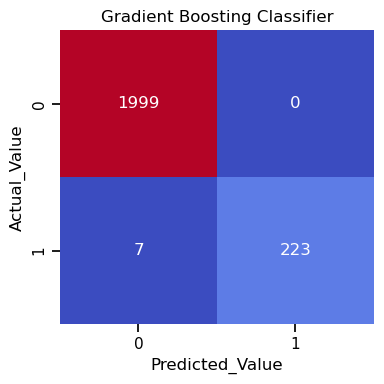

In [27]:
# Plotting the Confusion Matrix for Gradient Boosting

gr_model = trained_models["GradientBoosting"]

cm_gr = confusion_matrix(y_test, gr_model.predict(x_test))
plt.figure(figsize=(4,4))
sns.set_context('notebook',font_scale = 1)
sns.heatmap(cm_gr,annot=True,fmt='d', cmap="coolwarm", cbar=False)
plt.title('Gradient Boosting Classifier');
plt.xlabel("Predicted_Value")
plt.ylabel("Actual_Value")
plt.tight_layout()

<a id="s10"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 10 &nbsp;|&nbsp; Conclusion</p>
⬆️ <a href="#toc">Back to Table of Contents</a>

In [28]:
model_table = {'Model':["LogisticRgression", "DecisionTree", "RandomForest", "GradientBoosting"],
              'Accuracy':[0.98, 0.99, 0.99, 0.99],
              'F1 Score':[0.90, 0.98, 0.98, 0.98],
              'Precision':[0.87, 0.98, 1.0, 1.0],
              'Recall':[0.94, 0.97, 0.96, 0.97],
              'ROC AUC':[0.99, 0.98, 0.99, 0.99]}

compar_matrix = pd.DataFrame(model_table)

In [29]:
compar_matrix

,Model,Accuracy,F1 Score,Precision,Recall,ROC AUC
0,LogisticRgression,0.98,0.90,0.87,0.94,0.99
1,DecisionTree,0.99,0.98,0.98,0.97,0.98
2,RandomForest,0.99,0.98,1.00,0.96,0.99
3,GradientBoosting,0.99,0.98,1.00,0.97,0.99


<div style="border-radius:14px; padding:16px 20px; background:#f3f0ff; border-left:7px solid #7c3aed; font-size:114%">
<b style="color:#1a0533">🏆 Final Analysis:</b>

Among all the evaluated models, the <b>Gradient Boosting classifier demonstrates the best overall performance</b> for fraud detection. With an <b>accuracy of 99.78%</b> and an <b>F1-score of 0.989</b>, it achieves an excellent balance between precision and recall.

The model attains a <b>recall of 0.9783 for fraud cases (class 1)</b>, indicating that it successfully identifies the vast majority of fraudulent transactions. This is crucial in a fraud detection system, where missing even a small number of fraud cases can result in significant financial loss.

Additionally, the <b>precision of 1.00</b> highlights that almost all transactions flagged as fraud are indeed fraudulent, meaning the model produces virtually no false alarms. This ensures that genuine users are not unnecessarily impacted.

The <b>ROC AUC score of 0.9999</b> further confirms the model's exceptional ability to distinguish between fraudulent and legitimate transactions across different thresholds.

While <b>Decision Tree and Random Forest models</b> also perform strongly with high accuracy and F1-scores, they slightly underperform compared to Gradient Boosting in terms of recall and overall balance. The <b>Logistic Regression model</b>, although effective, shows comparatively lower precision and F1-score.

Overall, the <b>Gradient Boosting model is the most reliable and robust choice</b> for this fraud detection task, offering superior performance in identifying fraudulent transactions while minimizing false positives.
</div>

<a id="s10"></a>
# <p style="background: linear-gradient(135deg, #1a0533 0%, #7c3aed 100%); font-family: Trebuchet MS; color:white; font-size:145%; text-align:center; border-radius:14px; padding:12px;">Step 10 &nbsp;|&nbsp; Model and Scaler Export for Deployment </p>
⬆️ <a href="#toc">Back to Table of Contents</a>

In [31]:
#Save the model along with Scaler
import joblib

model_path = 'gr_model.joblib'
joblib.dump(gr_model, model_path)

scaler_path = 'scaler.joblib'
joblib.dump(scaler, scaler_path)

['scaler.joblib']

<div style="border-radius:14px; padding:18px; background: linear-gradient(135deg, #1a0533, #7c3aed); color:white; font-size:120%; text-align:center; margin-top:10px">
<b>🔐 Thank you for exploring this project. Stay alert and aware — fraud never sleeps!</b>
</div>